# 01. Data tour and the leakage trap

This notebook is a walkthrough: every cell is finished, so read the text, run the cell, and look at the output. It covers milestones M1 and M2 of the ML plan (`context/ml.md`):

1. What a play-by-play row is, and how much data we have.
2. EPA, the main efficiency number, explained with one team.
3. The **as-of rule**, which decides what the model is allowed to know before a game.
4. A **leakage bug on purpose**: a season average used in week 3 makes a model look brilliant, and the leakage test catches it.
5. The evaluation harness reproducing the known Elo (0.2201) and market (0.2104) Brier scores.

Data: nflverse play-by-play (CC BY 4.0), cached per season under `data/raw/ml/`. The first run downloads anything missing (about 300 MB for 1999-2025); after that it is read from disk.

Everything here stays inside the **development window, 2006-2019**, except the last section, which re-scores 2010-2025 only to prove the harness reproduces numbers we already know. The 2020-2025 holdout is otherwise untouched (decision D2).

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "nflelo").is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nflelo import data as elo_data, evaluate, config
from nflelo.ml import data as D, asof
from nflelo.ml.features import team_efficiency as te
from nflelo.ml.features.leaky_demo import build_leaky_season_average
from nflelo.ml.eval import baselines, walk_forward, metrics, calibration, bootstrap, windows

plt.rcParams.update({"figure.figsize": (9, 3.6), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
pd.set_option("display.width", 140)
INK, ACCENT, MUTED, BAD = "#1f2a44", "#2f6fdf", "#9aa3b2", "#d1495b"

## 1. What a play-by-play row is

nflverse records every snap of every game since 1999: one row per play, with about 370 columns. Most are bookkeeping. The handful we use describe the situation (down, distance, field position, clock), what happened (play type, yards), and two model outputs computed by nflfastR:

- **EP (expected points)**: how many points the offense can expect from this down, distance, and field position, before the snap.
- **EPA (expected points added)**: EP after the play minus EP before it. A 6-yard gain on 3rd and 5 is worth a lot more than a 6-yard gain on 3rd and 15, and EPA captures that.
- **WP (win probability)**: the offense's chance of winning, before the snap.

Here is one real play, Lamar Jackson in week 1 of 2019.

In [2]:
pbp_2019 = D.load_pbp([2019])
row = pbp_2019[(pbp_2019["posteam"] == "BAL") & (pbp_2019["week"] == 1) & (pbp_2019["play_type"] == "pass")
               & (pbp_2019["passer_player_name"] == "L.Jackson")].iloc[0]
cols = ["game_id", "qtr", "time", "down", "ydstogo", "yardline_100", "posteam", "defteam", "play_type",
        "yards_gained", "ep", "epa", "success", "wp", "desc"]
row[cols].to_frame("value")

,value
game_id,2019_01_BAL_MIA
qtr,1.0
time,14:09
down,1.0
ydstogo,10.0
yardline_100,40.0
posteam,BAL
defteam,MIA
play_type,pass
yards_gained,7.0


Notice what is **not** there: `D.load_pbp` drops every betting-market column (`spread_line`, `total_line`, `vegas_wp`, and the rest) as it loads. Decision D3 says the market is a benchmark we score against, never an input, so feature code never even sees it.

In [3]:
print("columns loaded:", pbp_2019.shape[1])
print("market columns left:", [c for c in pbp_2019.columns if D.is_market_column(c)])
del pbp_2019

columns loaded: 366
market columns left: []


### How much data

Rows per season, from the cache manifest. A row is any play, including kickoffs, punts, penalties, and timeouts. The seasons grew in 2021 when the regular season went from 16 to 17 games.

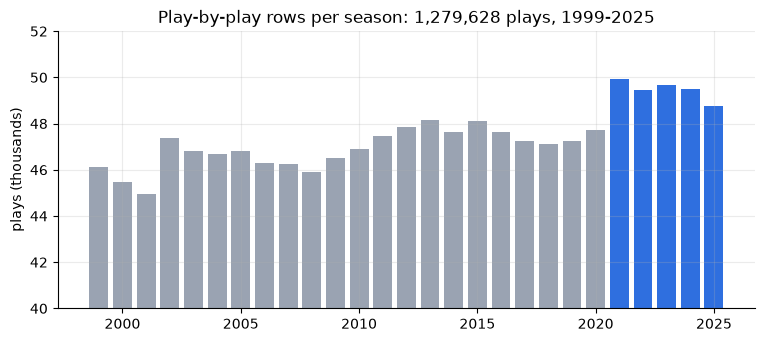

In [4]:
counts = pd.Series(D.pbp_row_counts()).loc[1999:2025]
fig, ax = plt.subplots()
ax.bar(counts.index, counts.values / 1000, color=[ACCENT if s >= 2021 else MUTED for s in counts.index])
ax.set_ylabel("plays (thousands)")
ax.set_title(f"Play-by-play rows per season: {counts.sum():,} plays, {counts.index.min()}-{counts.index.max()}")
ax.set_ylim(40, 52)
plt.show()

## 2. EPA with one team: the 2019 Ravens

Features don't use every row. `team_efficiency.clean_plays` keeps real snaps only: passes and runs with an EPA, no two-point tries, no plays wiped out by penalties, and no **garbage time** (when one team's win probability is below 5% or above 95%, both sides play differently and the stats mislead).

The 2019 Ravens had one of the best offenses on record. Below is their offensive EPA per play, week by week, next to the league average. Each dot is one game.

707,172 rows loaded, 418,430 kept as real non-garbage snaps


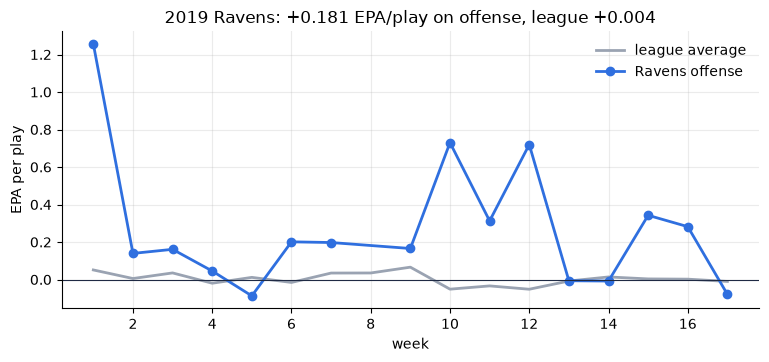

In [5]:
cols = te.PLAY_COLUMNS + ["season", "week", "two_point_attempt"]
pbp = D.load_pbp(range(2005, 2020), columns=cols)          # DEV seasons plus one warm-up season
sched = asof.add_asof(D.load_schedules(range(2005, 2020)))
plays = te.clean_plays(pbp)
print(f"{len(pbp):,} rows loaded, {len(plays):,} kept as real non-garbage snaps")

p19 = plays[plays["game_id"].str.startswith("2019_")].merge(sched[["game_id", "week", "game_type"]], on="game_id")
p19 = p19[p19["game_type"] == "REG"]
bal = p19[p19["posteam"] == "BAL"].groupby("week_y")["epa"].mean()
league = p19.groupby("week_y")["epa"].mean()

fig, ax = plt.subplots()
ax.plot(league.index, league.values, color=MUTED, lw=2, label="league average")
ax.plot(bal.index, bal.values, "o-", color=ACCENT, lw=2, label="Ravens offense")
ax.axhline(0, color=INK, lw=0.8)
ax.set_xlabel("week"); ax.set_ylabel("EPA per play"); ax.legend(frameon=False)
ax.set_title(f"2019 Ravens: {p19.loc[p19.posteam == 'BAL', 'epa'].mean():+.3f} EPA/play on offense, "
             f"league {p19['epa'].mean():+.3f}")
plt.show()

Read it like this: on an average snap, the Ravens added nearly a fifth of a point more than an average offense would have from the same situation. Over roughly 65 snaps a game, that is a lot of points.

## 3. The as-of rule

A feature for a game may only use information that existed **before** the game. We make that precise with one timestamp per game, called `as_of`:

> `as_of` = the earliest kickoff in that game's (season, week).

That copies the weekly pipeline, which predicts the whole week on Wednesday. Week N may use everything through week N-1, but not the Thursday night game of week N, even for the Sunday games that come after it. Kickoff times are in Eastern time; when nflverse has no kickoff time (all of 1999), we use midnight, which can only make us know less, never more.

Here is week 10 of 2019. Every game shares the Thursday kickoff as its `as_of`.

In [6]:
wk = sched[(sched["season"] == 2019) & (sched["week"] == 10)].sort_values("kickoff")
wk[["game_id", "kickoff", "as_of"]].head(6)

,game_id,kickoff,as_of
3873,2019_10_LAC_OAK,2019-11-07 20:20:00-05:00,2019-11-07 20:20:00-05:00
3874,2019_10_DET_CHI,2019-11-10 13:00:00-05:00,2019-11-07 20:20:00-05:00
3875,2019_10_BAL_CIN,2019-11-10 13:00:00-05:00,2019-11-07 20:20:00-05:00
3876,2019_10_BUF_CLE,2019-11-10 13:00:00-05:00,2019-11-07 20:20:00-05:00
3877,2019_10_ATL_NO,2019-11-10 13:00:00-05:00,2019-11-07 20:20:00-05:00
3878,2019_10_NYG_NYJ,2019-11-10 13:00:00-05:00,2019-11-07 20:20:00-05:00


The feature builder applies the rule for every game at once: it sums each team's plays from games that kicked off strictly before `as_of`, over the current season plus last season (last season's plays count half by default, `prev_weight=0.5`). Here are the Ravens' features going into their week 10 game.

In [7]:
feats = te.build_features(pbp, sched)
g = wk[(wk["home_team"] == "BAL") | (wk["away_team"] == "BAL")].iloc[0]
side = "home" if g["home_team"] == "BAL" else "away"
feats.loc[g["game_id"], [c for c in feats.columns if c.startswith(side + "_off")]].to_frame(g["game_id"]).round(3)

,2019_10_BAL_CIN
away_off_epa_all,0.069
away_off_epa_pass,0.104
away_off_epa_rush,0.027
away_off_sr,0.453
away_off_plays,443.000
away_off_plays_prev,1009.000


`off_plays` counts this season's snaps through week 9 and `off_plays_prev` counts 2018's. The EPA here is lower than the full-season number in the chart above because it blends in the 2018 Ravens and covers only the first eight games of 2019.

## 4. A leakage bug, on purpose

Leakage means a feature quietly contains information from after the prediction time. It is the most common way sports models fool their builders, because the model looks great in testing and then fails live.

The classic version: use each team's **full-season** EPA as a feature. For a week 3 game, that average includes weeks 3 to 17, so it includes the very game we are predicting. `leaky_demo.build_leaky_season_average` does exactly that. Let's build a one-feature model both ways:

- feature = (home offense EPA − home defense EPA allowed) − (away offense EPA − away defense EPA allowed)
- a logistic regression, trained walk-forward: to predict season S it is fit only on seasons before S
- scored on 2008-2019 regular-season games from week 3 on

In [8]:
leaky = build_leaky_season_average(pbp, sched)

def net(f):
    return (f["home_off_epa_all"] - f["home_def_epa_all"]) - (f["away_off_epa_all"] - f["away_def_epa_all"])

from sklearn.linear_model import LogisticRegression

g = sched[(sched["game_type"] == "REG") & sched["season"].between(2006, 2019)].copy()
g["y"] = evaluate.outcome(g)
g["x_honest"] = net(feats).reindex(g["game_id"]).to_numpy()
g["x_leaky"] = net(leaky).reindex(g["game_id"]).to_numpy()
games = elo_data.load_games()
elo = baselines.baseline_frame(games, (2006, 2019), require_market=False).set_index("game_id")
g["p_elo"] = elo["p_elo_v2"].reindex(g["game_id"]).to_numpy()
g["market"] = elo[baselines.MARKET_COL].reindex(g["game_id"]).to_numpy()   # benchmark only

def logistic_on(col):
    def fit_predict(train, test):
        train = train[train["y"] != 0.5]
        model = LogisticRegression(C=1e6).fit(train[[col]], (train["y"] == 1).astype(int))
        return model.predict_proba(test[[col]])[:, 1]
    return fit_predict

for col in ("x_honest", "x_leaky"):
    g["p_" + col[2:]] = walk_forward.walk_forward_predict(g, (2008, 2019), logistic_on(col))

scored = g[g["season"].between(2008, 2019) & (g["week"] >= 3) & g["market"].notna()]
rows = {name: metrics.win_metrics(scored["y"], scored[col])
        for name, col in [("honest EPA", "p_honest"), ("LEAKY EPA", "p_leaky"),
                          ("Elo v2", "p_elo"), ("market (benchmark)", "market")]}
table = pd.DataFrame(rows).T[["n", "brier", "accuracy"]]
table.round(4)

,n,brier,accuracy
honest EPA,2648.0,0.2224,0.6446
LEAKY EPA,2648.0,0.1885,0.7203
Elo v2,2648.0,0.2166,0.6461
market (benchmark),2648.0,0.2089,0.6722


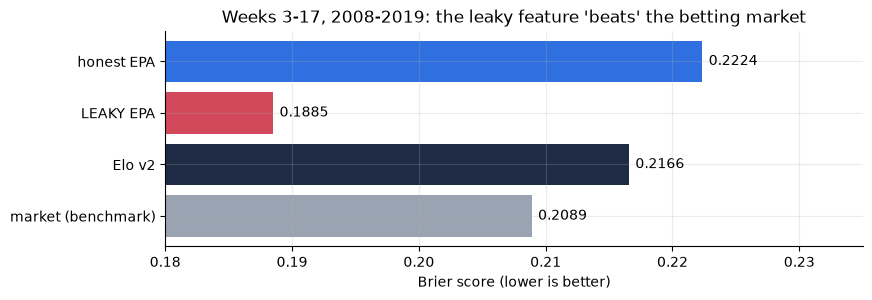

In [9]:
fig, ax = plt.subplots(figsize=(9, 2.8))
colors = [ACCENT, BAD, INK, MUTED]
ax.barh(table.index[::-1], table["brier"][::-1], color=colors[::-1])
for i, v in enumerate(table["brier"][::-1]):
    ax.text(v + 0.0005, i, f"{v:.4f}", va="center")
ax.set_xlim(0.18, 0.235); ax.set_xlabel("Brier score (lower is better)")
ax.set_title("Weeks 3-17, 2008-2019: the leaky feature 'beats' the betting market")
plt.show()

The leaky model scores far better than Elo and even beats the betting market, which no simple one-feature model should do. That is the tell: **if a result is too good to be true, look for leakage first.**

### The leakage test catches it

The fix is the as-of rule, and the test that proves it is simple: build the features, then scramble **everything** from games at or after `as_of` (EPA, win probability, play types, scores), rebuild, and check nothing changed. An honest builder can't tell the difference. The leaky one can. Week 3 of 2019 includes a Thursday game, so this also checks that Thursday's result stays out of Sunday's features.

In [10]:
wk3 = sched[(sched["season"] == 2019) & (sched["week"] == 3)].sort_values("kickoff")
check_games = list(wk3["game_id"].iloc[[0, 1, -1]])      # the Thursday game, a Sunday game, Monday night
small_pbp = pbp[pbp["season"].isin([2018, 2019])]
small_sched = sched[sched["season"].isin([2018, 2019])]

honest_check = asof.leakage_check(te.build_features, small_pbp, small_sched, check_games).assign(builder="honest")
leaky_check = asof.leakage_check(build_leaky_season_average, small_pbp, small_sched, check_games).assign(builder="leaky")
pd.concat([honest_check, leaky_check])[["builder", "game_id", "changed", "leak_free"]]

,builder,game_id,changed,leak_free
0,honest,2019_03_TEN_JAX,0,True
1,honest,2019_03_CIN_BUF,0,True
2,honest,2019_03_CHI_WAS,0,True
0,leaky,2019_03_TEN_JAX,4,False
1,leaky,2019_03_CIN_BUF,4,False
2,leaky,2019_03_CHI_WAS,4,False


The same check runs in the test suite on small synthetic data (`tests/ml/test_leakage.py`), including this leaky builder as a positive control: if the leaky builder ever passed, the test itself would be broken.

## 5. The harness reproduces known numbers

Before trusting any new model score, the harness has to reproduce numbers we already know. On REG games 2010-2025, the Elo report (`nflelo.evaluate.compare_on_test`) gives Elo v2 a Brier of 0.2201 and the market 0.2104. The harness computes them independently from its own baseline columns. (This window overlaps the 2020-2025 holdout, so it needs `allow_holdout=True`; it is a reproduction, not a model evaluation.)

In [11]:
ref = evaluate.compare_on_test(games, {"elo_v2": config.DEFAULT_CONFIG}, windows.REPRODUCTION)
full = baselines.baseline_frame(games, windows.REPRODUCTION, allow_holdout=True, require_market=False)
mk = full[full[baselines.MARKET_COL].notna()]

repro = pd.DataFrame([
    {"check": "Elo v2, all games", "n": len(full), "harness": metrics.win_metrics(full["y"], full["p_elo_v2"])["brier"],
     "reference": ref["all"].iloc[0]["brier"]},
    {"check": "market, games with moneylines", "n": len(mk),
     "harness": metrics.win_metrics(mk["y"], mk[baselines.MARKET_COL])["brier"],
     "reference": ref["market"].set_index("model").loc["market (vig removed)", "brier"]},
])
repro["difference"] = repro["harness"] - repro["reference"]
repro.round(6)

,check,n,harness,reference,difference
0,"Elo v2, all games",4175,0.220075,0.220075,0.0
1,"market, games with moneylines",4174,0.210426,0.210426,0.0


Both match exactly. Now the development-window baselines, which every future model must beat. All four are scored on the same 2006-2019 games (those with moneylines), and the paired bootstrap gives a 95% interval for how far Elo trails the market.

In [12]:
dev = baselines.baseline_frame(games, windows.DEV, require_market=True)
cols = {"coin flip": "p_coin_flip", "home-win rate": "p_home_rate", "Elo v2": "p_elo_v2",
        "market (benchmark)": baselines.MARKET_COL}
dev_table = pd.DataFrame({k: {**metrics.win_metrics(dev["y"], dev[c]), "ece": calibration.ece(dev["y"], dev[c])}
                          for k, c in cols.items()}).T.sort_values("brier")
ci = bootstrap.paired_bootstrap(dev["y"], dev["p_elo_v2"], dev[baselines.MARKET_COL])
print(f"Elo minus market Brier: {ci['diff']:+.4f}, 95% CI [{ci['ci_low']:+.4f}, {ci['ci_high']:+.4f}]")
dev_table[["n", "brier", "logloss", "accuracy", "ece"]].round(4)

Elo minus market Brier: +0.0072, 95% CI [+0.0044, +0.0101]


,n,brier,logloss,accuracy,ece
market (benchmark),3450.0,0.2106,0.6096,0.6635,0.0182
Elo v2,3450.0,0.2178,0.6255,0.6411,0.0154
home-win rate,3450.0,0.2451,0.6847,0.5661,0.0069
coin flip,3450.0,0.2493,0.6931,0.4339,0.0659


Calibration asks a different question from Brier: when a model says 70%, does the home team win about 70% of the time? Points on the diagonal are perfectly calibrated. Elo and the market are both close; the market is sharper, meaning it is willing to give more extreme probabilities and is right to.

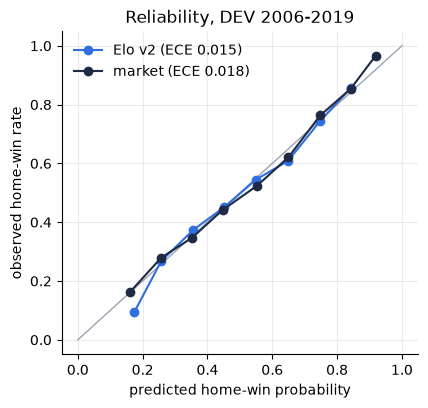

In [13]:
fig, ax = plt.subplots(figsize=(4.6, 4.2))
ax.plot([0, 1], [0, 1], color=MUTED, lw=1)
for name, col, color in [("Elo v2", "p_elo_v2", ACCENT), ("market", baselines.MARKET_COL, INK)]:
    t = calibration.reliability_table(dev["y"], dev[col], bins=10)
    t = t[t["n"] >= 30]
    ax.plot(t["mean_pred"], t["observed"], "o-", color=color, label=f"{name} (ECE {calibration.ece(dev['y'], dev[col]):.3f})")
ax.set_xlabel("predicted home-win probability"); ax.set_ylabel("observed home-win rate")
ax.set_title("Reliability, DEV 2006-2019"); ax.legend(frameon=False, loc="upper left")
plt.show()

## What to take away

- Play-by-play gives about 1.27 million plays from 1999 to 2025. EPA per play is the core efficiency measure, and garbage time and non-plays are filtered out before anything is averaged.
- The as-of rule (earliest kickoff of the week) is enforced in one place, and a test proves it: scrambling the future changes nothing.
- A season-average feature is the classic leak. It made a one-feature model look better than the betting market, and the leakage test flags it right away.
- The harness reproduces Elo 0.2201 and market 0.2104 exactly, so its other numbers can be trusted. On DEV the bar to clear is Elo at about 0.218 and the market at about 0.211.

**Known limitation:** nflfastR's EP and WP models were trained on many seasons, including seasons after the ones we predict. So a 2010 EPA value is computed with a model that saw later football. This is a small, accepted leak in the *definition* of EPA, not in which games we use, and every public EPA analysis shares it.

Next is M3: the first real model (logistic regression on as-of efficiency features, then opponent adjustment), which has to beat Elo on DEV with a paired interval that excludes zero.